In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, StandardScaler, MinMaxScaler

# Задаём названия колонок вручную (в файле нет заголовка)
columns = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']
df = pd.read_csv("car.csv", header=None, names=columns)

print(f"Размер: {df.shape}")
df.head(10)

Размер: (1728, 7)


,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc
5,vhigh,vhigh,2,2,med,high,unacc
6,vhigh,vhigh,2,2,big,low,unacc
7,vhigh,vhigh,2,2,big,med,unacc
8,vhigh,vhigh,2,2,big,high,unacc
9,vhigh,vhigh,2,4,small,low,unacc


In [3]:
print("=== Пропуски по колонкам ===")
print(df.isnull().sum())
print(f"\nВсего пропусков: {df.isnull().sum().sum()}")

=== Пропуски по колонкам ===
buying      0
maint       0
doors       0
persons     0
lug_boot    0
safety      0
class       0
dtype: int64

Всего пропусков: 0


=== Пропуски после добавления ===
        Пропусков  % от всех
buying         86       4.98
doors          86       4.98
safety         86       4.98


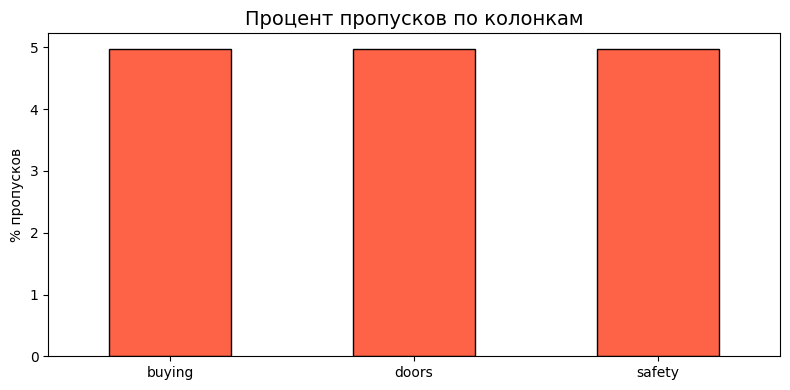

In [4]:
# В датасете нет пропусков — добавим искусственно для демонстрации
# Случайно заменяем ~5% значений на NaN в трёх колонках
np.random.seed(42)
df_missing = df.copy()

for col in ['buying', 'safety', 'doors']:
    missing_idx = np.random.choice(df_missing.index,
                                   size=int(len(df_missing) * 0.05),
                                   replace=False)
    df_missing.loc[missing_idx, col] = np.nan

print("=== Пропуски после добавления ===")
missing = df_missing.isnull().sum()
missing_pct = (missing / len(df_missing) * 100).round(2)
print(pd.DataFrame({'Пропусков': missing, '% от всех': missing_pct})
      .query('Пропусков > 0'))

# Визуализация
plt.figure(figsize=(8, 4))
missing_pct[missing_pct > 0].plot(kind='bar', color='tomato', edgecolor='black')
plt.title("Процент пропусков по колонкам", fontsize=14)
plt.ylabel("% пропусков")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("missing_values.png", dpi=150)
plt.show()

In [5]:
df_cleaned = df_missing.copy()

# Все признаки категориальные → заполняем модой
for col in ['buying', 'safety', 'doors']:
    mode_val = df_cleaned[col].mode()[0]
    df_cleaned[col] = df_cleaned[col].fillna(mode_val)
    print(f"{col:10s}: заполнено модой = '{mode_val}'")

print(f"\nПропусков после обработки: {df_cleaned.isnull().sum().sum()}")

buying    : заполнено модой = 'vhigh'
safety    : заполнено модой = 'high'
doors     : заполнено модой = '5more'

Пропусков после обработки: 0


In [6]:
print("=== Уникальные значения по колонкам ===")
for col in df_cleaned.columns:
    print(f"{col:12s}: {df_cleaned[col].unique().tolist()}")

=== Уникальные значения по колонкам ===
buying      : ['vhigh', 'high', 'med', 'low']
maint       : ['vhigh', 'high', 'med', 'low']
doors       : ['2', '5more', '3', '4']
persons     : ['2', '4', 'more']
lug_boot    : ['small', 'med', 'big']
safety      : ['low', 'med', 'high']
class       : ['unacc', 'acc', 'vgood', 'good']


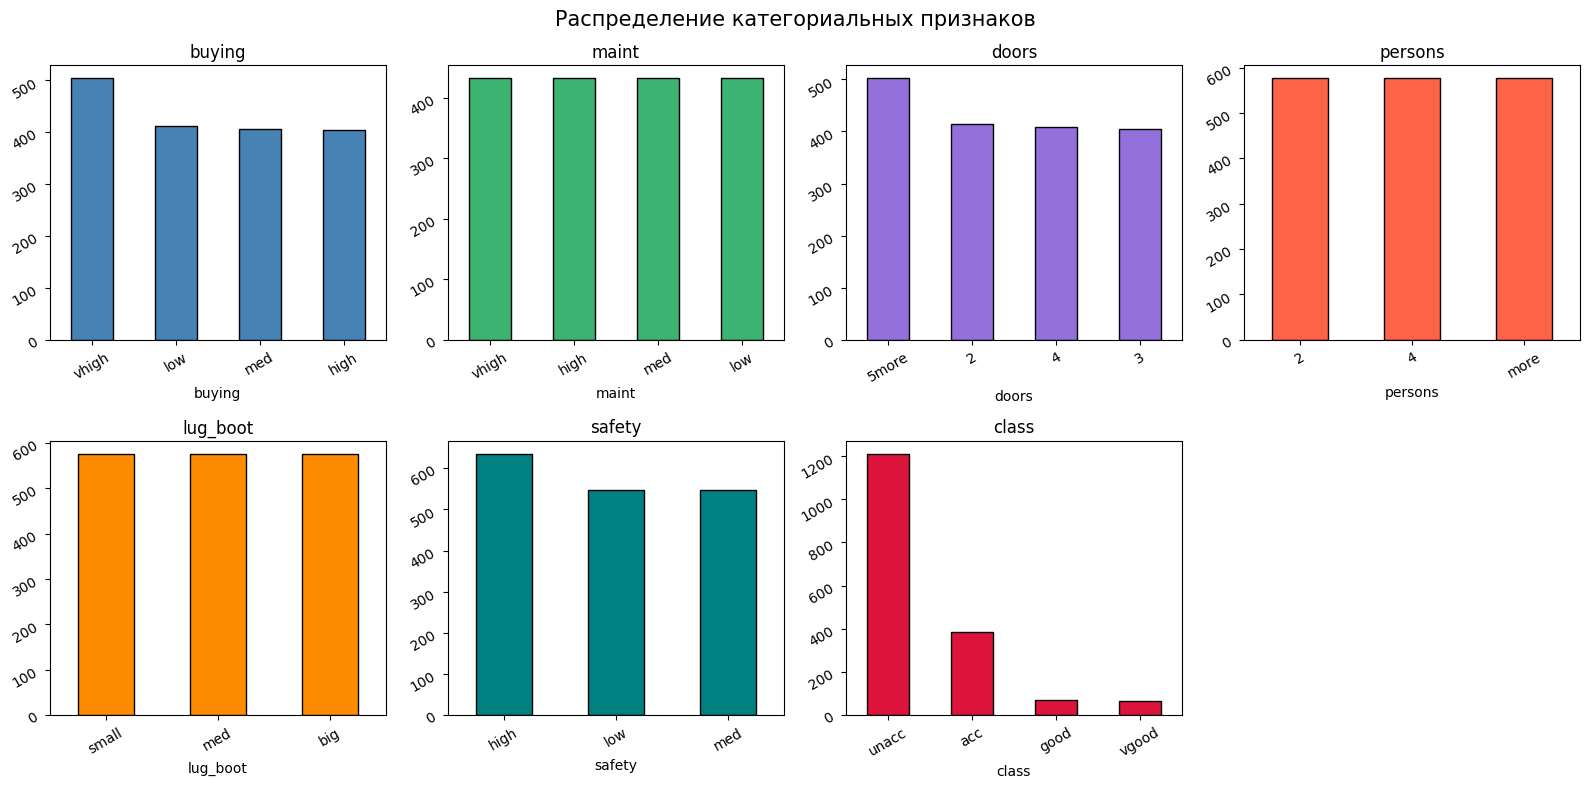

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flat

colors = ['steelblue', 'mediumseagreen', 'mediumpurple',
          'tomato', 'darkorange', 'teal', 'crimson']

for ax, col, color in zip(axes, df_cleaned.columns, colors):
    df_cleaned[col].value_counts().plot(kind='bar', ax=ax,
                                        color=color, edgecolor='black')
    ax.set_title(col, fontsize=12)
    ax.tick_params(rotation=30)

# Скрываем лишний subplot
axes[-1].set_visible(False)

plt.suptitle("Распределение категориальных признаков", fontsize=15)
plt.tight_layout()
plt.savefig("categorical_distribution.png", dpi=150)
plt.show()

In [8]:
df_label = df_cleaned.copy()
le = LabelEncoder()

for col in df_label.columns:
    df_label[col] = le.fit_transform(df_label[col])

print("=== Label Encoding ===")
print("\nОригинал:")
print(df_cleaned.head())
print("\nПосле Label Encoding:")
print(df_label.head())

=== Label Encoding ===

Оригинал:
  buying  maint doors persons lug_boot safety  class
0  vhigh  vhigh     2       2    small    low  unacc
1  vhigh  vhigh     2       2    small    med  unacc
2  vhigh  vhigh     2       2    small   high  unacc
3  vhigh  vhigh     2       2      med    low  unacc
4  vhigh  vhigh     2       2      med   high  unacc

После Label Encoding:
   buying  maint  doors  persons  lug_boot  safety  class
0       3      3      0        0         2       1      2
1       3      3      0        0         2       2      2
2       3      3      0        0         2       0      2
3       3      3      0        0         1       1      2
4       3      3      0        0         1       0      2


In [9]:
# Ordinal Encoding — задаём явный порядок для каждого признака
ordinal_categories = [
    ['low', 'med', 'high', 'vhigh'],   # buying
    ['low', 'med', 'high', 'vhigh'],   # maint
    ['2', '3', '4', '5more'],          # doors
    ['2', '4', 'more'],                # persons
    ['small', 'med', 'big'],           # lug_boot
    ['low', 'med', 'high'],            # safety
    ['unacc', 'acc', 'good', 'vgood'] # class
]

oe = OrdinalEncoder(categories=ordinal_categories)
df_ordinal = pd.DataFrame(
    oe.fit_transform(df_cleaned),
    columns=df_cleaned.columns
)

print("=== Ordinal Encoding (с заданным порядком) ===")
print("\nОригинал:")
print(df_cleaned.head())
print("\nПосле Ordinal Encoding:")
print(df_ordinal.head())

=== Ordinal Encoding (с заданным порядком) ===

Оригинал:
  buying  maint doors persons lug_boot safety  class
0  vhigh  vhigh     2       2    small    low  unacc
1  vhigh  vhigh     2       2    small    med  unacc
2  vhigh  vhigh     2       2    small   high  unacc
3  vhigh  vhigh     2       2      med    low  unacc
4  vhigh  vhigh     2       2      med   high  unacc

После Ordinal Encoding:
   buying  maint  doors  persons  lug_boot  safety  class
0     3.0    3.0    0.0      0.0       0.0     0.0    0.0
1     3.0    3.0    0.0      0.0       0.0     1.0    0.0
2     3.0    3.0    0.0      0.0       0.0     2.0    0.0
3     3.0    3.0    0.0      0.0       1.0     0.0    0.0
4     3.0    3.0    0.0      0.0       1.0     2.0    0.0


In [10]:
df_ohe = pd.get_dummies(df_cleaned, columns=df_cleaned.columns[:-1])

print(f"Размер ДО One-Hot:    {df_cleaned.shape}")
print(f"Размер ПОСЛЕ One-Hot: {df_ohe.shape}")
print(f"Новых колонок: {df_ohe.shape[1] - df_cleaned.shape[1]}")
print("\nНовые колонки:")
print(df_ohe.columns.tolist())

Размер ДО One-Hot:    (1728, 7)
Размер ПОСЛЕ One-Hot: (1728, 22)
Новых колонок: 15

Новые колонки:
['class', 'buying_high', 'buying_low', 'buying_med', 'buying_vhigh', 'maint_high', 'maint_low', 'maint_med', 'maint_vhigh', 'doors_2', 'doors_3', 'doors_4', 'doors_5more', 'persons_2', 'persons_4', 'persons_more', 'lug_boot_big', 'lug_boot_med', 'lug_boot_small', 'safety_high', 'safety_low', 'safety_med']


In [11]:
# Масштабируем Ordinal Encoded данные (они числовые)
num_cols = df_ordinal.columns.tolist()

scaler_std = StandardScaler()
df_std = pd.DataFrame(
    scaler_std.fit_transform(df_ordinal),
    columns=[f"{c}_std" for c in num_cols]
)

scaler_mm = MinMaxScaler()
df_mm = pd.DataFrame(
    scaler_mm.fit_transform(df_ordinal),
    columns=[f"{c}_mm" for c in num_cols]
)

print("=== Оригинал (после Ordinal Encoding) ===")
print(df_ordinal.describe().round(2))
print("\n=== StandardScaler ===")
print(df_std.describe().round(2))
print("\n=== MinMaxScaler ===")
print(df_mm.describe().round(2))

=== Оригинал (после Ordinal Encoding) ===
        buying    maint    doors  persons  lug_boot   safety    class
count  1728.00  1728.00  1728.00  1728.00   1728.00  1728.00  1728.00
mean      1.58     1.50     1.58     1.00      1.00     1.05     0.41
std       1.14     1.12     1.14     0.82      0.82     0.83     0.74
min       0.00     0.00     0.00     0.00      0.00     0.00     0.00
25%       1.00     0.75     1.00     0.00      0.00     0.00     0.00
50%       2.00     1.50     2.00     1.00      1.00     1.00     0.00
75%       3.00     2.25     3.00     2.00      2.00     2.00     1.00
max       3.00     3.00     3.00     2.00      2.00     2.00     3.00

=== StandardScaler ===
       buying_std  maint_std  doors_std  persons_std  lug_boot_std  \
count     1728.00    1728.00    1728.00      1728.00       1728.00   
mean         0.00       0.00       0.00         0.00          0.00   
std          1.00       1.00       1.00         1.00          1.00   
min         -1.38      -

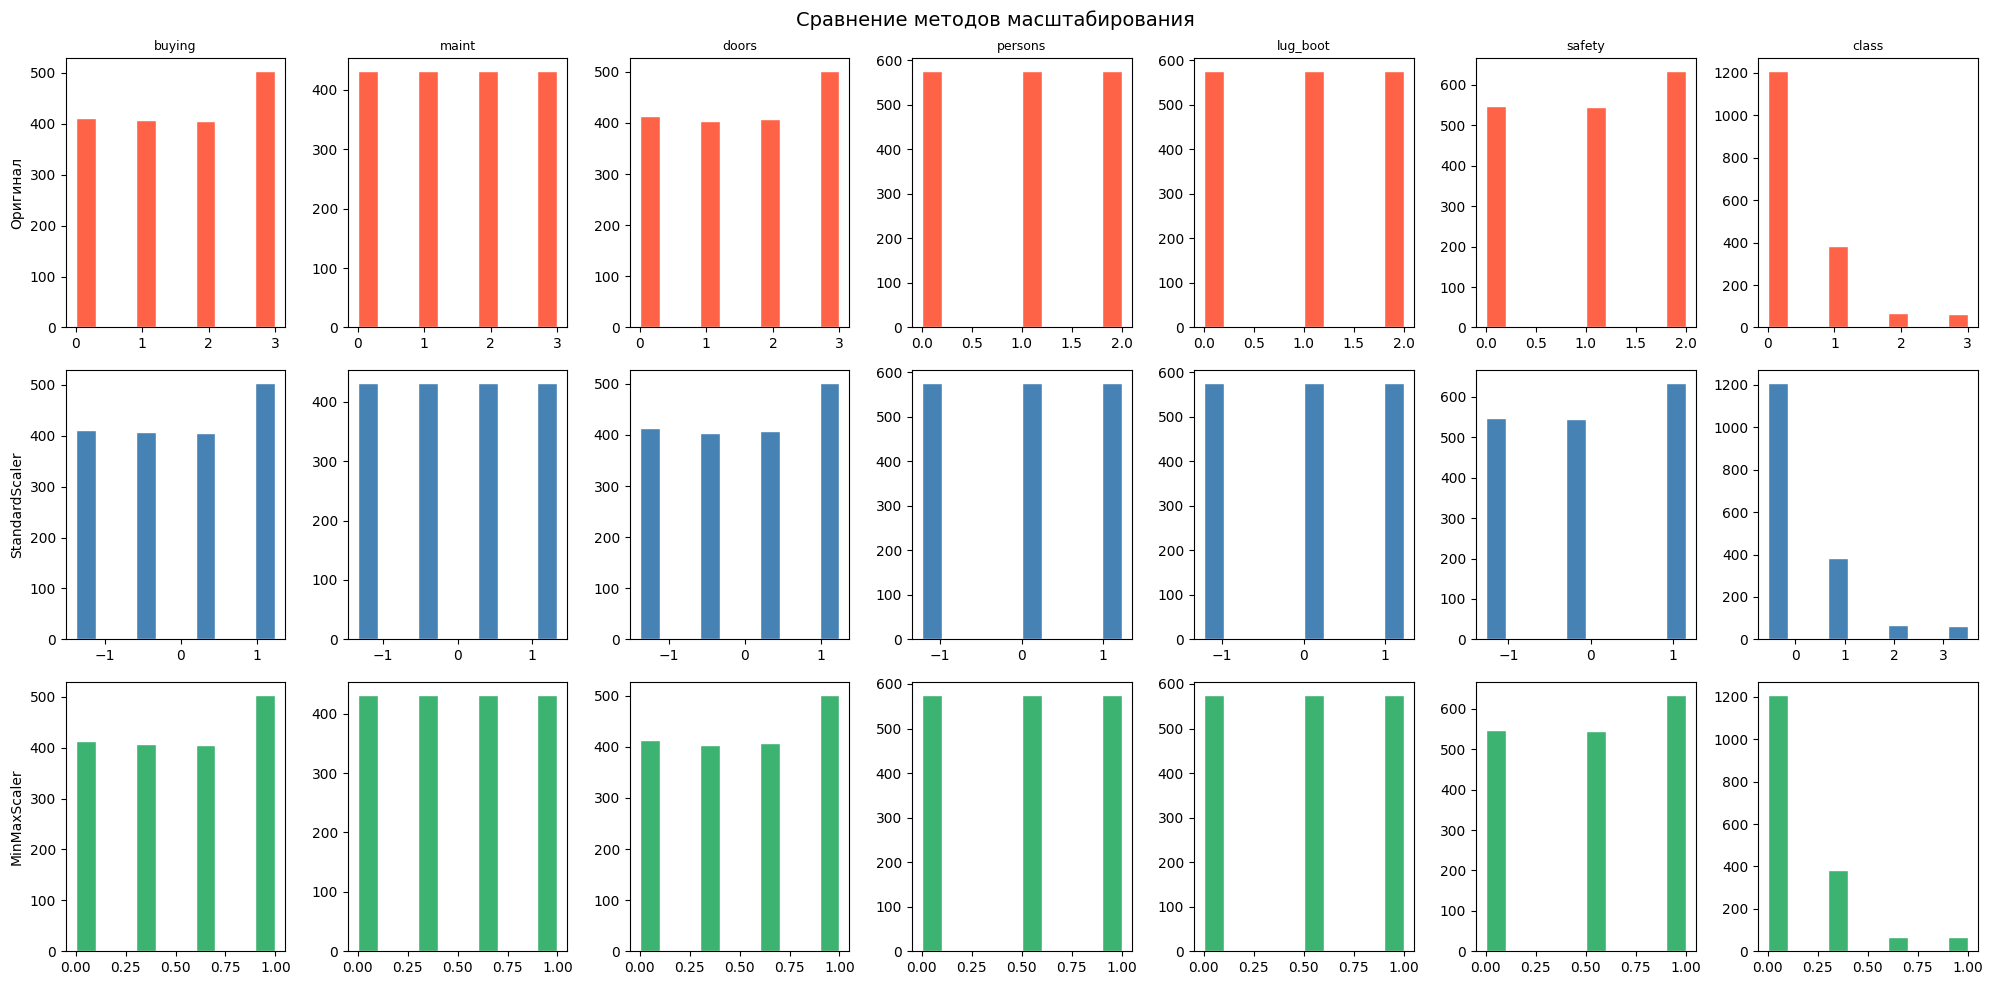

In [12]:
fig, axes = plt.subplots(3, 7, figsize=(20, 10))

for i, col in enumerate(num_cols):
    axes[0][i].hist(df_ordinal[col], bins=10,
                    color='tomato', edgecolor='white')
    axes[0][i].set_title(col, fontsize=9)
    if i == 0:
        axes[0][i].set_ylabel("Оригинал", fontsize=10)

    axes[1][i].hist(df_std[f"{col}_std"], bins=10,
                    color='steelblue', edgecolor='white')
    if i == 0:
        axes[1][i].set_ylabel("StandardScaler", fontsize=10)

    axes[2][i].hist(df_mm[f"{col}_mm"], bins=10,
                    color='mediumseagreen', edgecolor='white')
    if i == 0:
        axes[2][i].set_ylabel("MinMaxScaler", fontsize=10)

plt.suptitle("Сравнение методов масштабирования", fontsize=14)
plt.tight_layout()
plt.savefig("scaling_comparison.png", dpi=150)
plt.show()